# Exercise: PCA

Peter Ralph  
2026-01-30

# Some more about the weather

You are by now familiar with the [local weather
data](../slides/weather_intro.html). Below I have “done PCA on this
data”. I would like you to interpret the results.

Concretely: suppose that we have been tasked with understanding on which
days ants are likely to be active on counters in Eugene. A myrmecologist
suggested that weather probably has a lot to do with it. So, we decided
to use the local weather as a predictor. We have ant activity data from
houses across Eugene, but it is at a daily level, and we don’t know what
variables to use (temperature at noon? pressure at 9pm?) So, we decided
to summarize the large number of weather observations using PCA. Then
(imagine) we found that higher values of PC3 are strongly associated
with more ant activity. What is this telling us about conditions in
which ants tend to be active (in this dataset)?

So: read the code, print things out and investigate, and talk through
descriptions of the figures.

Questions:

1.  What does each point in the PCA plots represent?
2.  What does each line in the loading plots represent?
3.  Explain in words what differentiates high values from low values on
    each of the PCs.

Unzip [the data](../data/weather_data.zip) and put it in
[`data/weather_data/`](data/weather_data).

# The code

In [1]:
import numpy as np
import pandas as pd
import plotnine as p9
import glob
import sklearn.decomposition

def make_date(x):
    """
    Makes a datetime object out of the Date and Time columns
    """
    return pd.to_datetime(x['Date'] + " " + x['Time'], format="%Y/%m/%d %I:%M %p")

def compute_precip(x):
    """
    Returns for each entry the amount of precipitation that has accumulated
    in the previous five minutes, inserting NA for any entry for which either:
        - the difference in accumulated precipitation is negative, or
        - the previous entry was not five minutes ago.
    """
    dt = x["Date"].diff().dt.seconds
    dp = np.maximum(0, x['Precip_Accum_mm'].diff()).mask(dt != 300, pd.NA)
    return dp

def read_weather_files(ddir):
    """
    Reads in all CSV files in the directory `ddir`, and returns a concatenated
    data frame. For each file, assumes that file names are of the form
    "something_CODE.csv"; and inserts "CODE into the "code" column of the result
    for that file.
    """
    wfiles = glob.glob(ddir + "/" + "*.csv")
    assert len(wfiles) > 0, "No files found."
    xl = []
    for f in wfiles:
        x = pd.read_csv(f).convert_dtypes()
        x['Date'] = make_date(x)
        x['code'] = f.split("/")[-1].split("_")[0] ## change "/" to "\\" on windows
        x['Precip_Amount_mm'] = compute_precip(x)
        xl.append(x)
    
    return pd.concat(xl)

weather = read_weather_files("data/weather_data")

In [2]:
use_cols = ['Temperature_C', 'Dew_Point_C', 'Humidity_%', 'Speed_kmh', 'Gust_kmh', 'Pressure_hPa', 'UV', 'Solar_w/m2', 'Precip_Amount_mm']
w = weather.copy()
for cn in use_cols:
    w[cn] /= w[cn].std()
X = (
    w
    .assign(
        hour=lambda df: df['Date'].dt.hour,
        day=lambda df: df['Date'].dt.dayofyear,
    )
    .pivot_table(
        values=use_cols,
        index=["code", "day"],
        columns=["hour"],
        aggfunc="mean",
    )
).dropna()

In [3]:
pca = sklearn.decomposition.PCA(n_components=4).fit(X)
pcs = pd.concat([
    X.index.to_frame().reset_index(drop=True),
    pd.DataFrame(
        pca.transform(X),
        columns=[f"PC{k+1}" for k in range(pca.n_components_)],
    )],
    axis=1,
)

In [8]:
X

Dew_Point_C                                                    \
hour                     0         1         2         3         4         5    
code        day                                                                 
KOREUGEN127 1      0.980049   0.94265  1.000627  1.015658   1.02532  1.035162   
            2      1.711909  1.719961  1.745371  1.540128  1.704036  1.709941   
            3      2.060661  1.877607  1.606514   1.55158  1.550506  1.566611   
            4      1.282277  1.228774  1.242552  1.294087  1.366736   1.36942   
            5       1.78259  1.807641  1.891564  1.916257  1.745371  1.739645   
...                     ...       ...       ...       ...       ...       ...   
KOREUGEN74  361    0.916525  0.874833  0.884674  0.884853  0.842981  0.873043   
            362    0.481167   0.58853  0.569563  0.281292  0.251588  0.468104   
            363     0.24899  0.294981  0.366156  0.286894  0.286302  0.293989   
            364    0.283719  0.261687  0.257851  0.239934  0.148348  0.053771   
            365   -0.589604 -0.571889 -0.634875 -0.563658 -0.510334 -0.497808   

                                                         ...        UV  \
hour                   6         7         8         9   ...        14   
code        day                                          ...             
KOREUGEN127 1    1.067729  1.083475  1.122305  1.163998  ...  0.121091   
            2    1.702962  1.756465  1.820346    1.8955  ...       0.0   
            3    2.124363  2.181087  2.161225  2.035789  ...  0.161455   
            4    1.445469  1.507024   1.60544   1.65107  ...       0.0   
            5    1.734634  1.795295  1.817304  1.941488  ...       0.0   
...                   ...       ...       ...       ...  ...       ...   
KOREUGEN74  361  0.841192  0.822225  0.870001  0.938356  ...  0.201819   
            362  0.474367  0.435359  0.444663   0.38275  ...       0.0   
            363  0.245255  0.175703  0.294086  0.496556  ...  0.252712   
            364 -0.077395 -0.091527  0.024336  0.289134  ...  0.282547   
            365 -0.391876  -0.24282 -0.173034 -0.079628  ...  0.080728   

                                                                   
hour                   15   16   17   18   19   20   21   22   23  
code        day                                                    
KOREUGEN127 1         0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
            2         0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
            3         0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
            4         0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
            5         0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
...                   ...  ...  ...  ...  ...  ...  ...  ...  ...  
KOREUGEN74  361       0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
            362       0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
            363  0.060546  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
            364  0.080728  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
            365       0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  

[3572 rows x 216 columns]

In [16]:
X.columns.to_frame().iloc[:,0].value_counts()

0
Dew_Point_C         24
Gust_kmh            24
Humidity_%          24
Precip_Amount_mm    24
Pressure_hPa        24
Solar_w/m2          24
Speed_kmh           24
Temperature_C       24
UV                  24
Name: count, dtype: int64

In [4]:
pls = (
    pd.DataFrame(pca.components_.T, index=X.columns, columns=[f"PC{k+1}" for k in range(pca.n_components_)])
    .reset_index(names=["variable", "hour"])
)

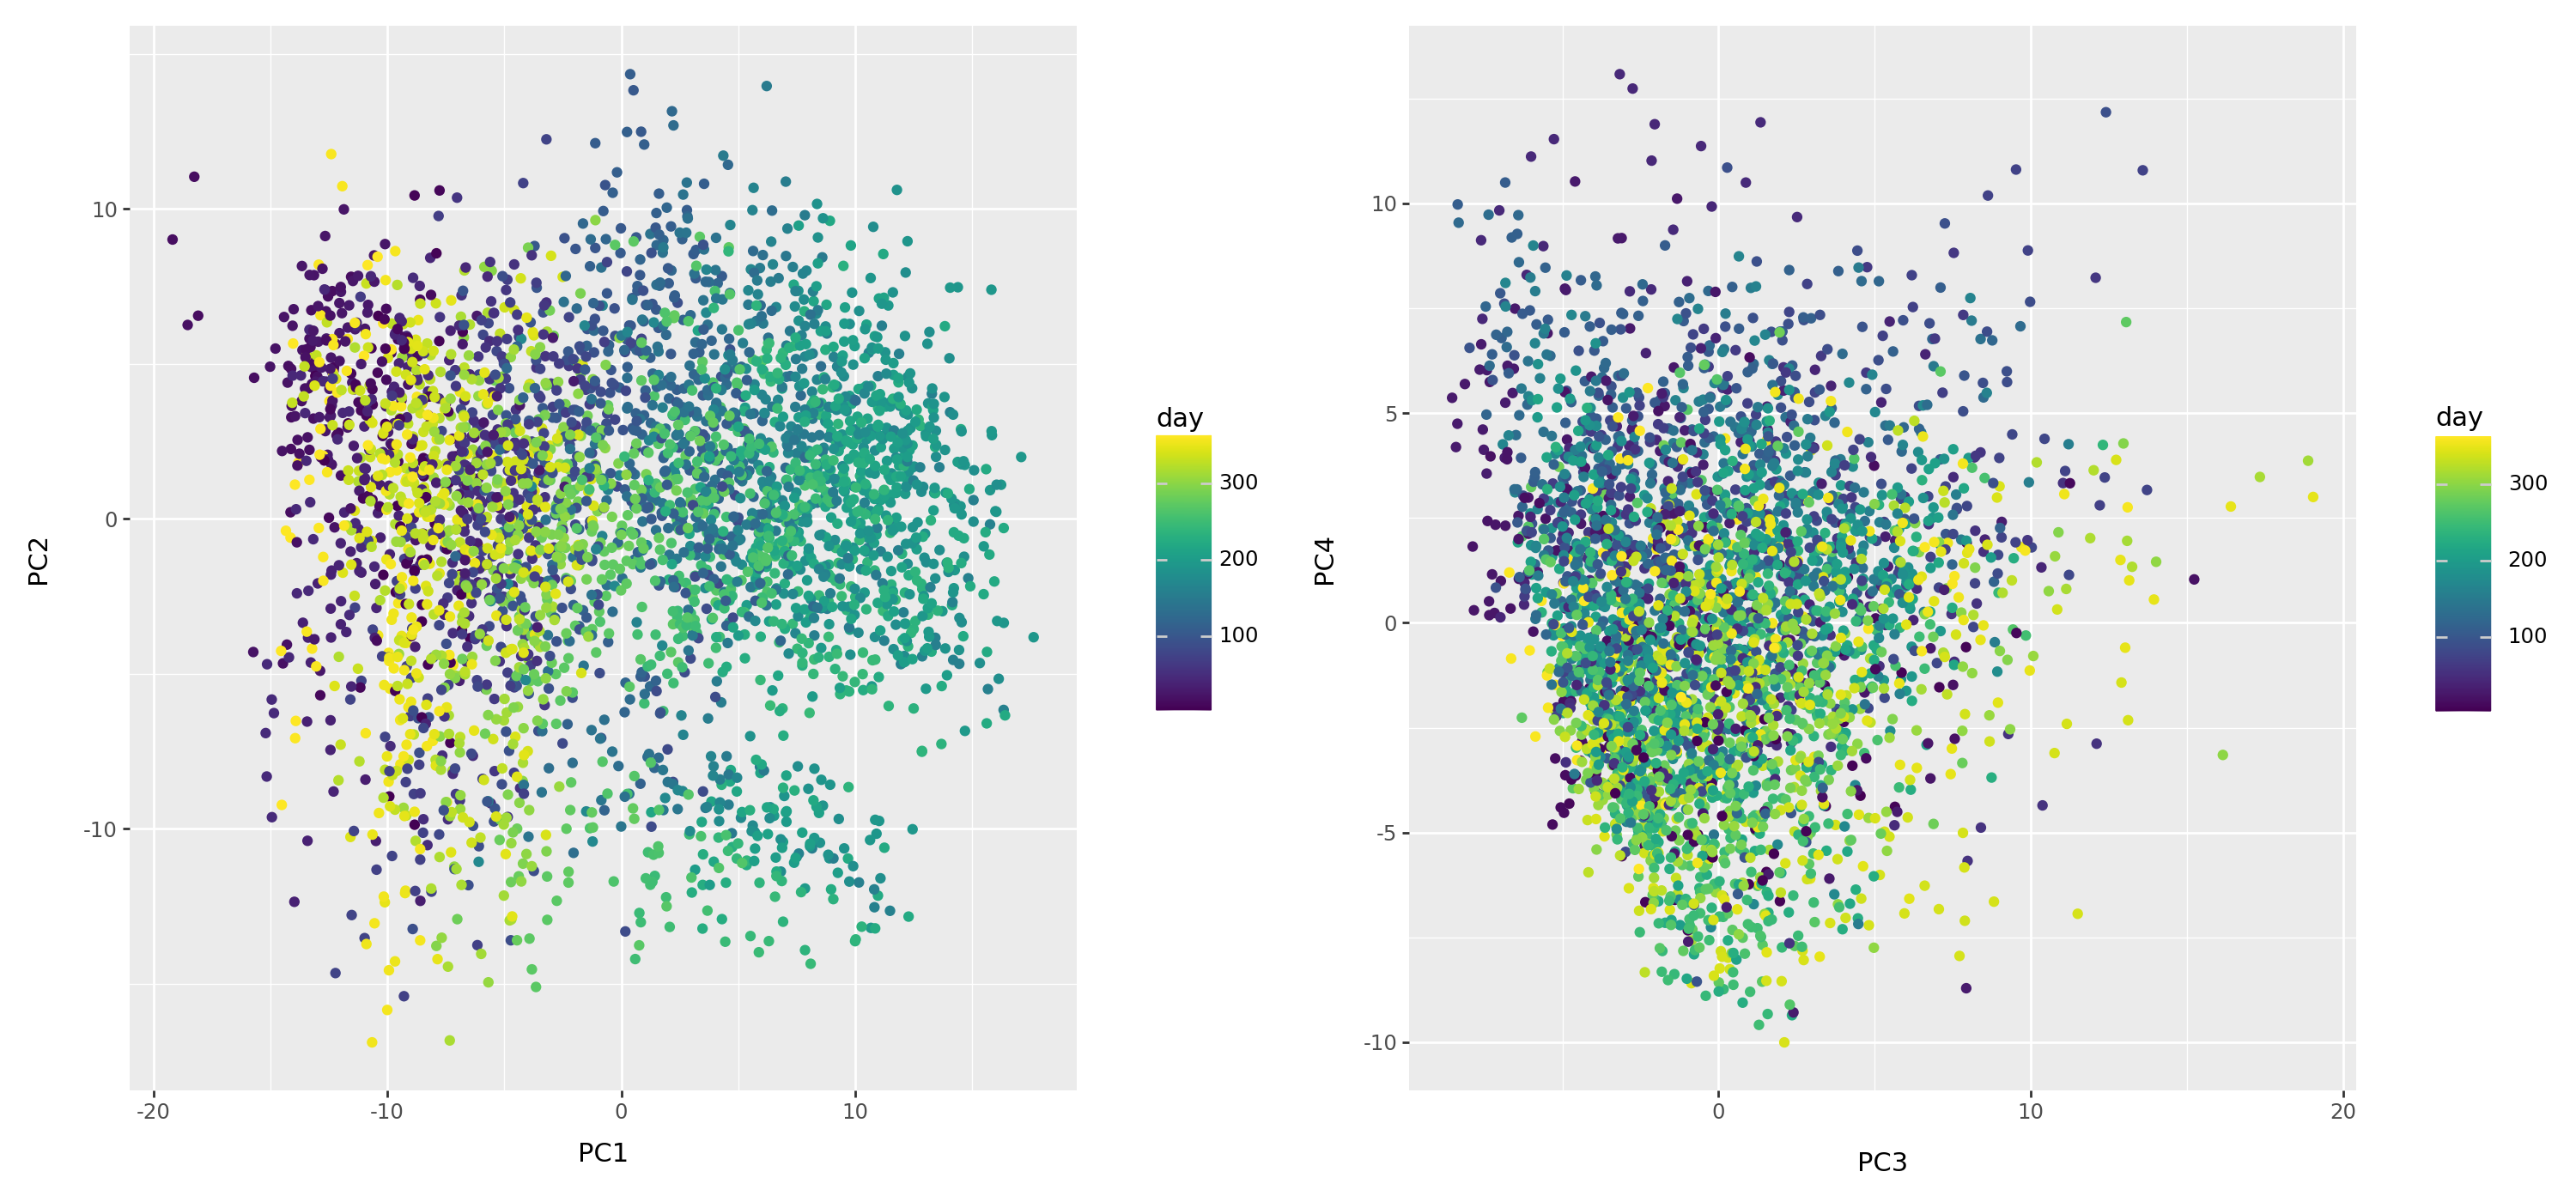

In [5]:
(
    pcs
    >>
    p9.ggplot(p9.aes(x='PC1', y="PC2", color="day"))
    + p9.geom_point()
) | (
    pcs
    >>
    p9.ggplot(p9.aes(x='PC3', y="PC4", color="day"))
    + p9.geom_point()
) + p9.theme(figure_size=(15,7))

In [19]:
pcs

,code,day,PC1,PC2,PC3,PC4
0,KOREUGEN127,1,-9.571011,0.421070,0.844704,-2.563114
1,KOREUGEN127,2,-8.524032,-1.337901,1.533005,-5.942581
2,KOREUGEN127,3,-6.871841,-1.793648,3.402069,-1.495288
3,KOREUGEN127,4,-8.460676,1.961880,4.284532,-3.407290
4,KOREUGEN127,5,-7.095739,2.017964,1.964728,-6.637107
...,...,...,...,...,...,...
3567,KOREUGEN74,361,-9.857882,-1.459715,0.676896,0.745760
3568,KOREUGEN74,362,-12.577298,1.505941,-0.253390,0.680610
3569,KOREUGEN74,363,-11.845527,-0.217430,-2.034707,1.230543
3570,KOREUGEN74,364,-12.934129,-0.294412,-3.104783,1.587950


In [26]:
pca.singular_values_**2 / ((X-pca.mean_)**2).sum().sum()

array([0.41706096, 0.17944043, 0.10459024, 0.09296429])

In [29]:
(pcs.loc[:,["PC1", "PC2", "PC3", "PC4"]]**2).sum(axis=0)

PC1    213964.664320
PC2     92058.270816
PC3     53657.902628
PC4     47693.442821
dtype: float64

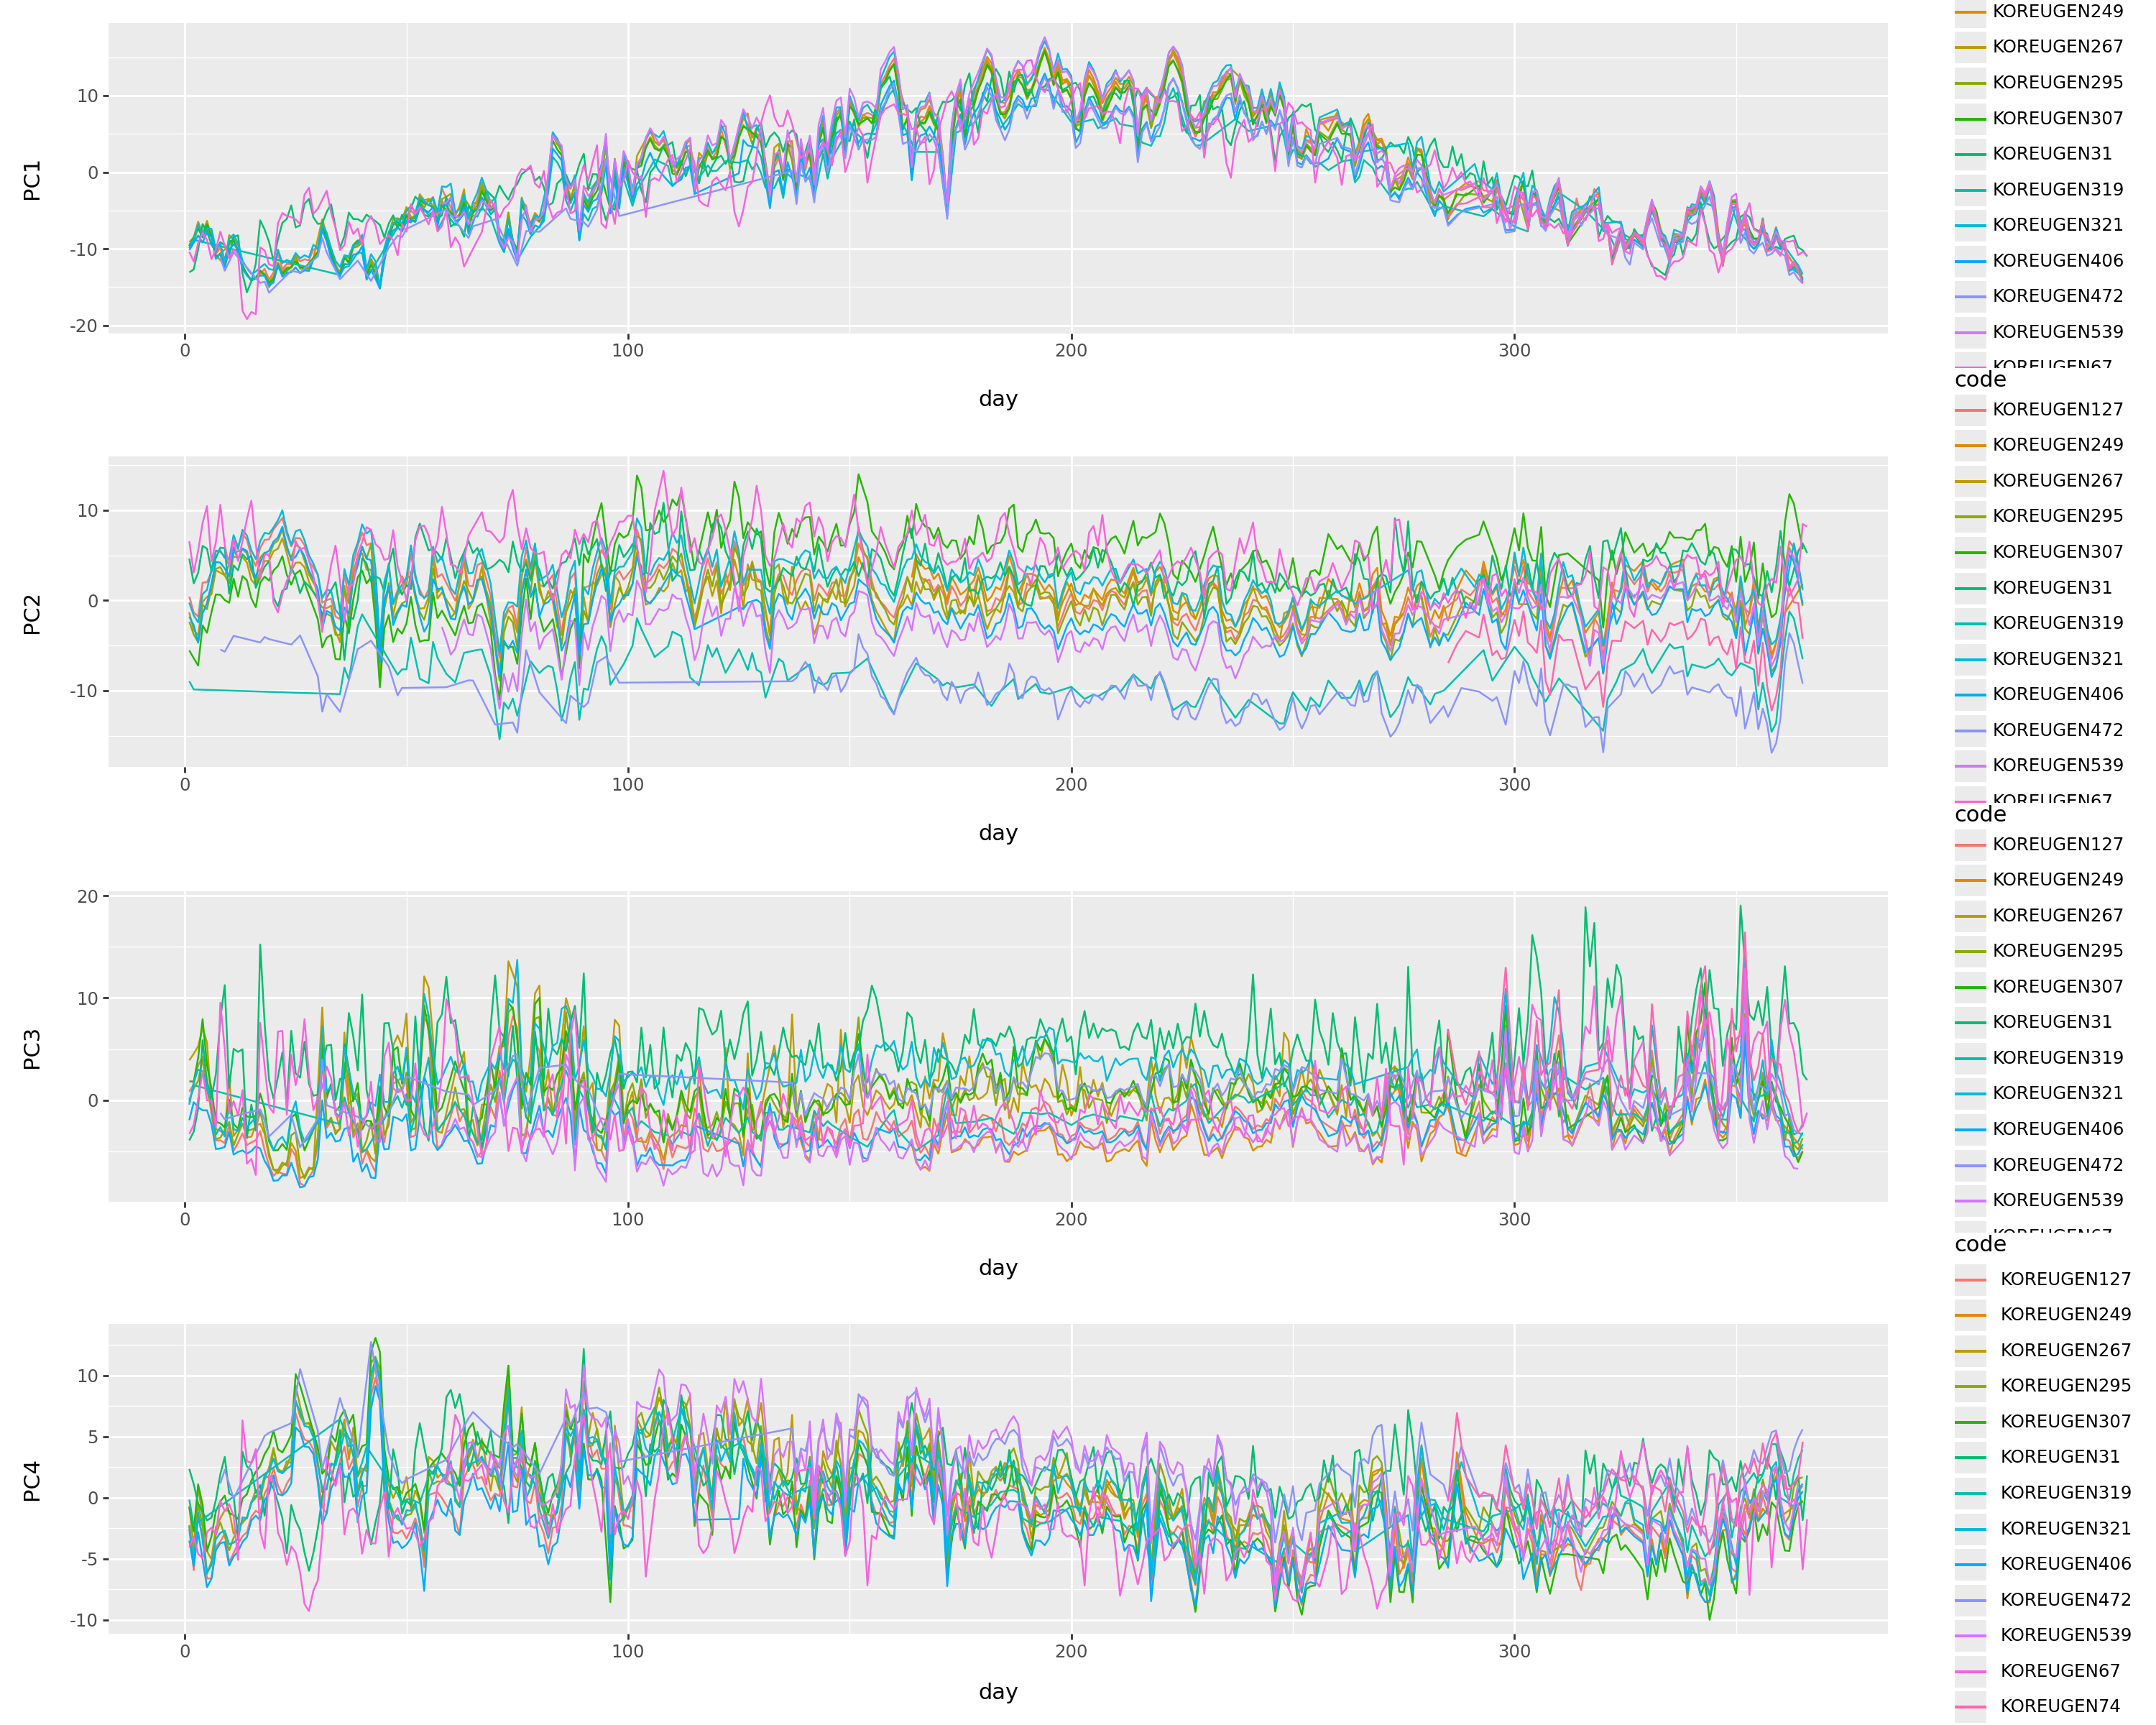

In [18]:
(
    pcs
    >>
    p9.ggplot(p9.aes(x='day', y="PC1", color="code"))
    + p9.geom_line()
) / (
    pcs
    >>
    p9.ggplot(p9.aes(x='day', y="PC2", color="code"))
    + p9.geom_line()
) / (
    pcs
    >>
    p9.ggplot(p9.aes(x='day', y="PC3", color="code"))
    + p9.geom_line()
) / (
    pcs
    >>
    p9.ggplot(p9.aes(x='day', y="PC4", color="code"))
    + p9.geom_line()
) + p9.theme(figure_size=(15,12))

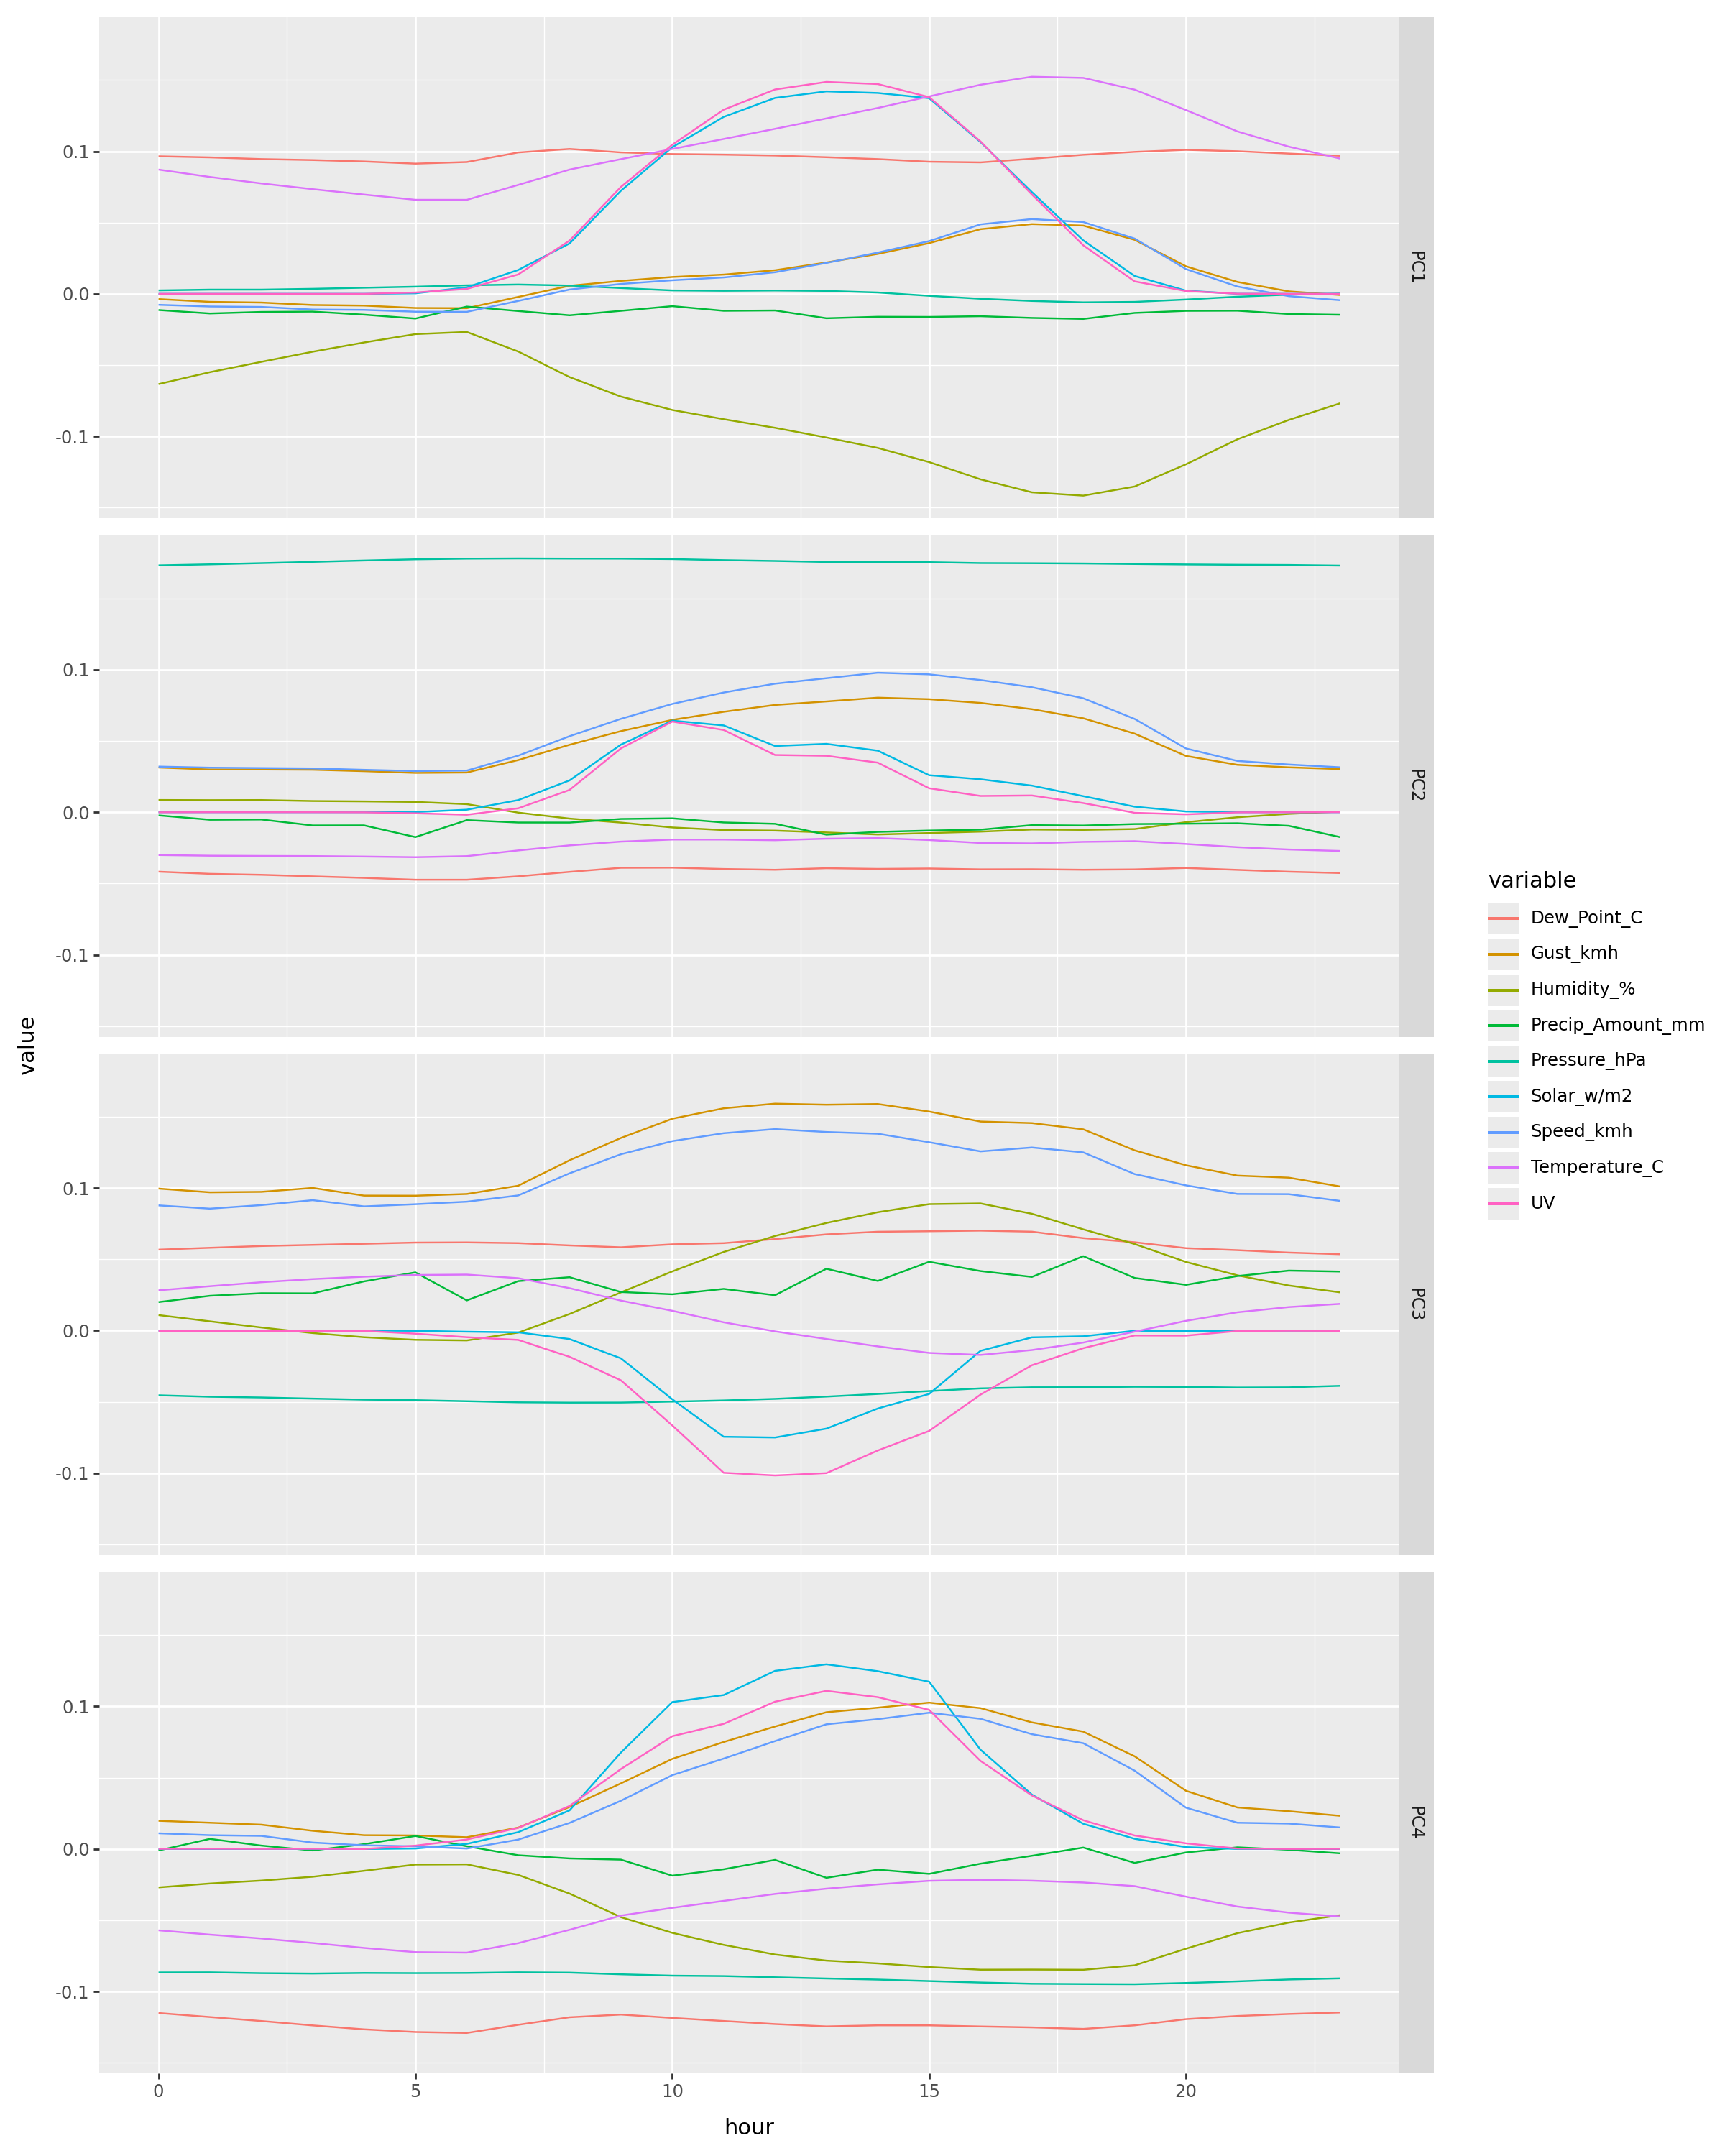

In [7]:
(
    pls
    .melt(id_vars=['variable','hour'], var_name='pc')
    >>
    p9.ggplot(p9.aes(x='hour', y='value', color='variable'))
    + p9.geom_line()
    + p9.facet_grid("pc")
) + p9.theme(figure_size=(12,15))